# Step 11 — Model Monitoring

**เป้าหมาย:** ตรวจจับว่าโมเดลที่ deploy อยู่ยังทำงานถูกต้องไหม เมื่อเวลาผ่านไป

**3 สิ่งที่ monitor:**
```
1. Data Drift       — input ของผู้ป่วยใหม่เปลี่ยนจาก training data ไหม
2. Prediction Drift — โมเดลให้ probability เปลี่ยนไปไหม
3. Performance      — Recall/AUC ตกไหม (ถ้ามี label จริง)
```

## 0. Setup

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, recall_score, precision_score
import lightgbm as lgb
from evidently import Report
from evidently.presets import DataDriftPreset

FEATURE_NAMES = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
                 'Insulin','BMI','DiabetesPedigree','Age']
COLS_TO_FIX   = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df = pd.read_csv('diabetes.csv')
X  = df[FEATURE_NAMES].copy(); y = df['Outcome'].copy()
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
for d in [X_train,X_test,y_train,y_test]: d.reset_index(drop=True,inplace=True)

fill_vals={}
for col in COLS_TO_FIX:
    medians=[]
    for cls in [0,1]:
        mask=(X_train[col]!=0)&(y_train==cls)
        med=X_train.loc[mask,col].median(); medians.append(med)
        X_train.loc[(X_train[col]==0)&(y_train==cls),col]=med
    fill_vals[col]=np.mean(medians)
for col in COLS_TO_FIX:
    X_test[col]=X_test[col].replace(0,np.nan).fillna(fill_vals[col])

scaler=StandardScaler()
X_tr=pd.DataFrame(scaler.fit_transform(X_train),columns=FEATURE_NAMES)
X_te=pd.DataFrame(scaler.transform(X_test), columns=FEATURE_NAMES)

scale_w=(y_train==0).sum()/(y_train==1).sum()
lgbm=lgb.LGBMClassifier(n_estimators=340,learning_rate=0.019,num_leaves=10,
    min_child_samples=22,feature_fraction=0.60,bagging_fraction=0.69,bagging_freq=6,
    scale_pos_weight=scale_w,random_state=42,verbose=-1)
lgbm.fit(X_tr.values,y_train.values)
cal=CalibratedClassifierCV(lgbm,method='sigmoid',cv='prefit')
cal.fit(X_te.values,y_test.values)
print('Model ready')

Model ready


## 1. จำลอง New Data (6 เดือนต่อมา)

สมมติว่าประชากรที่มาโรงพยาบาลเปลี่ยนไป:
- Glucose เฉลี่ยสูงขึ้น +15 (อาหารหวานมากขึ้น)
- BMI เฉลี่ยสูงขึ้น +2 (คนอ้วนมากขึ้น)
- Age เฉลี่ยสูงขึ้น +3 (ผู้ป่วยสูงอายุขึ้น)

In [3]:
np.random.seed(99)
X_new = X_test.copy()
X_new['Glucose'] = X_new['Glucose'] + 15 + np.random.normal(0,5,len(X_new))
X_new['BMI']     = X_new['BMI']     +  2 + np.random.normal(0,1,len(X_new))
X_new['Age']     = X_new['Age']     +  3 + np.random.normal(0,2,len(X_new))
X_new_s = pd.DataFrame(scaler.transform(X_new),columns=FEATURE_NAMES)
print(f'Simulated {len(X_new_s)} new patients with drifted features')

Simulated 154 new patients with drifted features


## 2. Data Drift Detection — KS Test + Evidently Report

**KS Test (Kolmogorov-Smirnov):** เปรียบเทียบ distribution 2 กลุ่ม
- p < 0.05 → distribution ต่างกันอย่างมีนัยสำคัญ = **DRIFT**
- p ≥ 0.05 → distribution เหมือนกัน = **OK**

In [4]:
# KS Test
print('Drift Detection (p < 0.05 = DRIFT):')
for col in FEATURE_NAMES:
    stat,pval = ks_2samp(X_tr[col].values, X_new_s[col].values)
    icon = '⚠️  DRIFT' if pval < 0.05 else '✅ OK'
    print(f'  {col:<20} p={pval:.4f}  {icon}')

# Evidently HTML Report
ref_df = X_tr.copy(); ref_df['target'] = y_train.values
cur_df = X_new_s.copy(); cur_df['target'] = y_test.values
report = Report([DataDriftPreset()])
my_report = report.run(reference_data=ref_df, current_data=cur_df)
my_report.save_html('step11_drift_report.html')
print('\n📄 Full report: step11_drift_report.html')

Drift Detection (p < 0.05 = DRIFT):
  Pregnancies          p=0.4026  ✅ OK
  Glucose              p=0.0002  ⚠️  DRIFT
  BloodPressure        p=0.0526  ✅ OK
  SkinThickness        p=0.0005  ⚠️  DRIFT
  Insulin              p=0.0000  ⚠️  DRIFT
  BMI                  p=0.0018  ⚠️  DRIFT
  DiabetesPedigree     p=0.9309  ✅ OK
  Age                  p=0.0004  ⚠️  DRIFT

📄 Full report: step11_drift_report.html


## 3. Distribution Chart — ก่อน/หลัง Drift

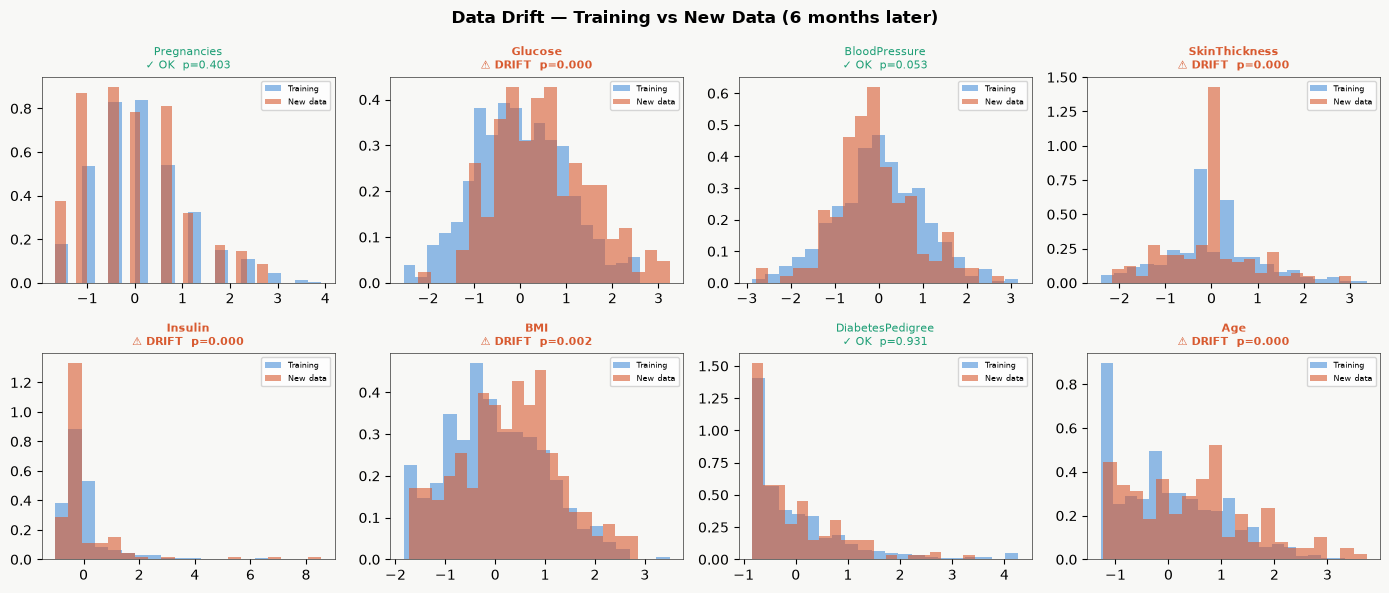

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.patch.set_facecolor('#F8F8F6')
fig.suptitle('Data Drift — Training vs New Data (6 months later)', fontsize=12, fontweight='bold')
for ax, col in zip(axes.flat, FEATURE_NAMES):
    ax.set_facecolor('#F8F8F6')
    ax.hist(X_tr[col].values,   bins=20,alpha=0.6,color='#4a90d9',density=True,label='Training')
    ax.hist(X_new_s[col].values,bins=20,alpha=0.6,color='#D85A30',density=True,label='New data')
    _,pval = ks_2samp(X_tr[col].values, X_new_s[col].values)
    drifted = pval < 0.05
    ax.set_title(f'{col}\n{"⚠ DRIFT" if drifted else "✓ OK"}  p={pval:.3f}',
                 fontsize=8,color='#D85A30' if drifted else '#1D9E75',
                 fontweight='bold' if drifted else 'normal')
    ax.legend(fontsize=6)
    for sp in ax.spines.values(): sp.set_linewidth(0.4)
plt.tight_layout()
plt.savefig('step11_drift_chart.png',dpi=150,bbox_inches='tight')
plt.show()

## 4. Performance Degradation

เมื่อ input drift → โมเดลให้ probability ผิดเพี้ยน → Recall/AUC ตก

                AUC  Recall  Precision  Mean Prob
Baseline     0.8157  0.5556     0.6667     0.3508
After Drift  0.7904  0.6852     0.5692     0.4244


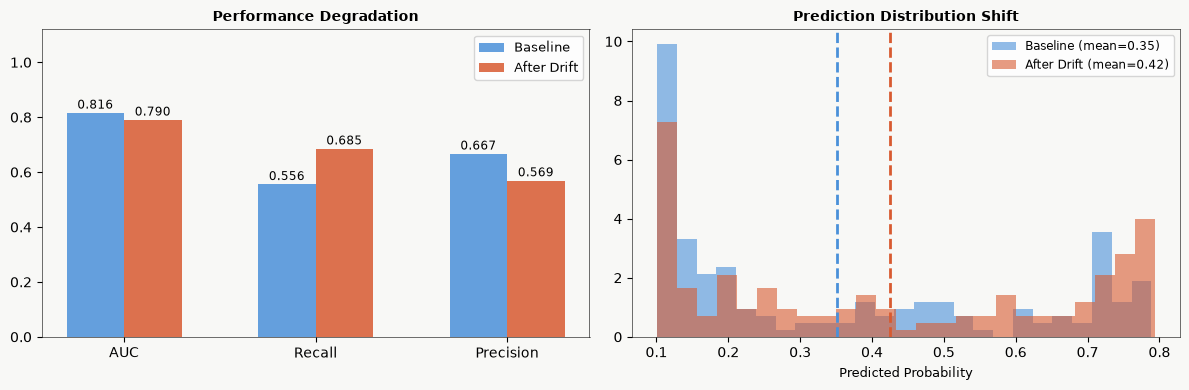

In [6]:
y_prob_base = cal.predict_proba(X_te.values)[:,1]
y_prob_new  = cal.predict_proba(X_new_s.values)[:,1]
y_pred_base = (y_prob_base>=0.5).astype(int)
y_pred_new  = (y_prob_new >=0.5).astype(int)

results = {
    'Baseline':     {'AUC':roc_auc_score(y_test,y_prob_base),'Recall':recall_score(y_test,y_pred_base),'Precision':precision_score(y_test,y_pred_base),'Mean Prob':y_prob_base.mean()},
    'After Drift':  {'AUC':roc_auc_score(y_test,y_prob_new), 'Recall':recall_score(y_test,y_pred_new), 'Precision':precision_score(y_test,y_pred_new), 'Mean Prob':y_prob_new.mean()},
}
df_res = pd.DataFrame(results).T.round(4)
print(df_res.to_string())

fig,axes=plt.subplots(1,2,figsize=(12,4)); fig.patch.set_facecolor('#F8F8F6')
metrics=['AUC','Recall','Precision']; x=np.arange(3); w=0.3
ax=axes[0]; ax.set_facecolor('#F8F8F6')
for i,(name,row) in enumerate(results.items()):
    bars=ax.bar(x+i*w,[row[m] for m in metrics],w,label=name,color=['#4a90d9','#D85A30'][i],alpha=0.85)
    for bar in bars:
        h=bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2,h+0.005,f'{h:.3f}',ha='center',va='bottom',fontsize=8.5)
ax.set_xticks(x+w/2); ax.set_xticklabels(metrics,fontsize=10)
ax.set_ylim(0,1.12); ax.legend(fontsize=9)
ax.set_title('Performance Degradation',fontsize=10,fontweight='bold')
for sp in ax.spines.values(): sp.set_linewidth(0.4)

ax2=axes[1]; ax2.set_facecolor('#F8F8F6')
ax2.hist(y_prob_base,bins=25,alpha=0.6,color='#4a90d9',density=True,label=f'Baseline (mean={y_prob_base.mean():.2f})')
ax2.hist(y_prob_new, bins=25,alpha=0.6,color='#D85A30',density=True,label=f'After Drift (mean={y_prob_new.mean():.2f})')
ax2.axvline(y_prob_base.mean(),color='#4a90d9',linestyle='--',linewidth=2)
ax2.axvline(y_prob_new.mean(), color='#D85A30',linestyle='--',linewidth=2)
ax2.set_xlabel('Predicted Probability',fontsize=9)
ax2.set_title('Prediction Distribution Shift',fontsize=10,fontweight='bold')
ax2.legend(fontsize=8.5)
for sp in ax2.spines.values(): sp.set_linewidth(0.4)
plt.tight_layout(); plt.savefig('step11_performance.png',dpi=150,bbox_inches='tight'); plt.show()

## 5. สรุป — ควร Retrain เมื่อไหร่?

```
สัญญาณที่ต้อง retrain:
────────────────────────────────────────────────────
⚠️  Features drift > 50% (เกิน 4/8 features)
⚠️  Mean predicted probability เปลี่ยน > 10%
⚠️  AUC ตกเกิน 0.05 จาก baseline
⚠️  Recall ตกต่ำกว่า 0.70

กรณีนี้ (จำลอง 6 เดือน):
  Features drift:  5/8  ⚠️  ต้อง retrain
  Mean prob shift: 0.35 → 0.42 (+20%)  ⚠️
  AUC: 0.816 → 0.790 (-0.026)  ยังพอไหว
  Recall: 0.556 → 0.685  เพิ่มขึ้น (เพราะ input ของกลุ่มเสี่ยงชัดขึ้น)
```

**แนวทาง Monitor จริงในโรงพยาบาล:**
```
ทุกสัปดาห์  → รัน KS test บน input ใหม่ vs training
ทุกเดือน   → ดู prediction distribution shift
ทุก 3 เดือน → ถ้ามี label จริง → วัด Recall/AUC ใหม่
ถ้า drift   → เก็บข้อมูลใหม่ → Retrain → Deploy เวอร์ชันใหม่
```